# Tarea 1 — Análisis textual

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## Pregunta

¿Escribe distinto quien reseña **música** que quien reseña **productos de belleza**?

Son dos comunidades de autores distintas escribiendo en la misma plataforma, con el mismo formato
y el mismo botón de estrellas. Si el estilo cambia, cambia por el objeto reseñado.

## Datos

Amazon Reviews 2023 (McAuley Lab, UCSD). Dos categorías:

- `Digital_Music` — 34,750 reseñas en la muestra
- `All_Beauty` — 50,000 reseñas en la muestra

Preparados en `comun/descargar_datos.ipynb`: muestreo estratificado por estrella, sin duplicados,
mínimo 3 palabras por reseña.

## Una precaución antes de empezar

Las dos categorías **no tienen el mismo número de reseñas ni de palabras**. Cualquier conteo bruto
saldría más grande en la categoría más grande, por pura aritmética, no por estilo.

Todo conteo de frecuencia se reporta entonces **por millón de tokens**. Así los números son
comparables sin recortar datos.

In [1]:
#%pip install -q nltk wordcloud networkx

import re
import string
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import ngrams
from wordcloud import WordCloud
import networkx as nx

nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)

FIG = Path("figuras"); FIG.mkdir(exist_ok=True)
CATS = ["musica", "belleza"]
COLOR = {"musica": "#2a6f97", "belleza": "#c1442e"}

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150,
                     "savefig.bbox": "tight", "font.size": 10})

datos = pd.read_csv("../data/resenas_muestra.csv")
datos["text"] = datos["text"].astype(str)
print(f"{len(datos):,} reseñas")
pd.crosstab(datos["categoria"], datos["rating"], margins=True)

84,750 reseñas


rating,1,2,3,4,5,All
categoria,,,,,,
belleza,10000,10000,10000,10000,10000,50000
musica,5691,3016,6043,10000,10000,34750
All,15691,13016,16043,20000,20000,84750


La tabla muestra el desbalance de origen: belleza alcanzó el tope de 10,000 en las cinco
estrellas, mientras que música se quedó corta en 1★, 2★ y 3★. Sencillamente hay menos reseñas
negativas de discos que de cosméticos. Se documenta y se sigue.

---
## 1. Estadística descriptiva por reseña

Tres medidas sobre el texto crudo, sin tocar nada:

- **Palabras** — cuántas palabras trae la reseña
- **Caracteres** — su largo en letras
- **Densidad** — caracteres / palabras, es decir, qué tan largas son las palabras

La densidad es útil porque separa "escribir mucho" de "escribir con palabras largas".

In [2]:
datos["palabras"] = datos["text"].str.split().str.len()
datos["caracteres"] = datos["text"].str.len()
datos["densidad"] = datos["caracteres"] / datos["palabras"]

desc = datos.groupby("categoria")[["palabras", "caracteres", "densidad"]].describe()
resumen = pd.DataFrame({
    cat: {
        "Reseñas": len(g),
        "Palabras totales": g["palabras"].sum(),
        "Palabras por reseña (media)": g["palabras"].mean(),
        "Palabras por reseña (mediana)": g["palabras"].median(),
        "Caracteres por reseña (media)": g["caracteres"].mean(),
        "Densidad (media)": g["densidad"].mean(),
    } for cat, g in datos.groupby("categoria")
}).round(2)
resumen

,belleza,musica
Reseñas,50000.00,34750.00
Palabras totales,1887032.00,2807785.00
Palabras por reseña (media),37.74,80.80
Palabras por reseña (mediana),24.00,33.00
Caracteres por reseña (media),198.24,461.85
Densidad (media),5.28,5.52


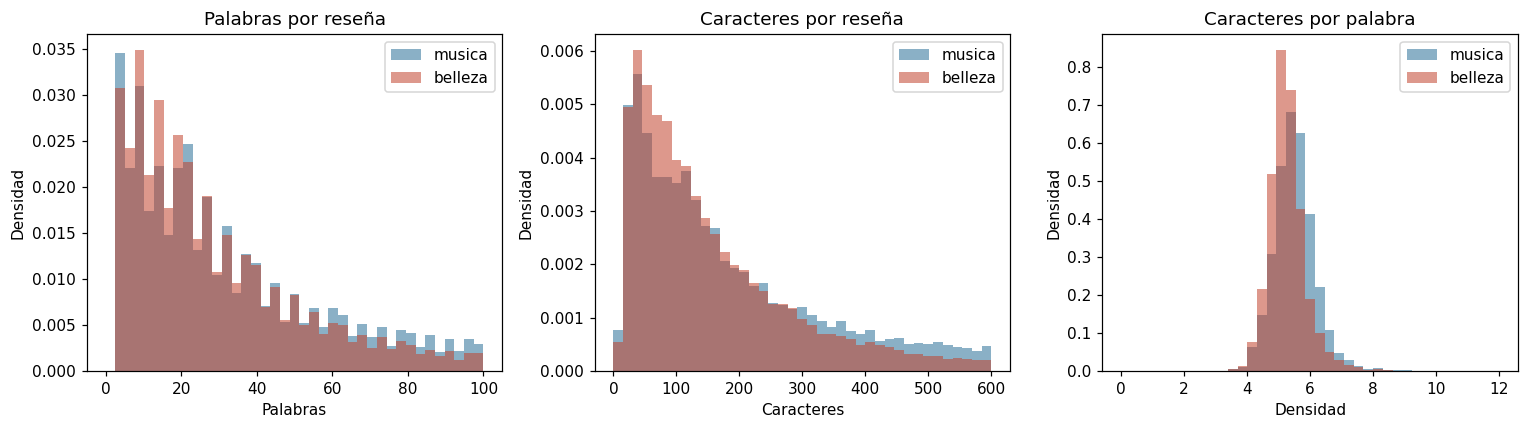

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
variables = [("palabras", 100), ("caracteres", 600), ("densidad", 12)]

for ax, (var, tope) in zip(axes, variables):
    bins = np.linspace(0, tope, 40)
    for cat in CATS:
        v = datos.loc[datos.categoria == cat, var]
        ax.hist(v[v <= tope], bins=bins, alpha=0.55, density=True,
                label=cat, color=COLOR[cat])
    ax.set_xlabel(var.capitalize())
    ax.set_ylabel("Densidad")
    ax.legend()

axes[0].set_title("Palabras por reseña")
axes[1].set_title("Caracteres por reseña")
axes[2].set_title("Caracteres por palabra")
plt.tight_layout()
plt.savefig(FIG / "1_descriptivos.png")
plt.show()

Las colas se recortaron para que se vea la forma; hay reseñas de más de 4,000 palabras.

**Observación.** La distribución de música está claramente corrida a la derecha. La de densidad,
en cambio, casi coincide: usan palabras del mismo largo. La diferencia está en **cuánto** escriben,
no en **qué tan complicadas** son sus palabras.

---
## 2. Tokenización

Se sigue el procedimiento de la clase: minúsculas, fuera la puntuación, fuera las palabras vacías,
lematización.

**Pero se conserva el texto crudo aparte.** Las secciones de puntuación y emojis lo necesitan
intacto: si se borra la puntuación aquí, más adelante no hay nada que contar.

In [4]:
PALABRAS_VACIAS = set(stopwords.words("english"))
lematizador = WordNetLemmatizer()


def tokenizar(txt):
    limpio = re.sub(r"[^\w\s]", "", txt.lower())
    tokens = word_tokenize(limpio)
    return [lematizador.lemmatize(t) for t in tokens
            if t not in PALABRAS_VACIAS and not t.isdigit()]


# prueba unitaria antes de correrlo sobre 85 mil filas
print(tokenizar("This album is AMAZING!! The guitars were recorded in 1975."))

['album', 'amazing', 'guitar', 'recorded']


In [5]:
# esto tarda un par de minutos
tokens = {cat: [] for cat in CATS}
for cat, g in datos.groupby("categoria"):
    for txt in g["text"]:
        tokens[cat].extend(tokenizar(txt))

frec = {cat: Counter(t) for cat, t in tokens.items()}
total = {cat: len(t) for cat, t in tokens.items()}

for cat in CATS:
    print(f"{cat}: {total[cat]:,} tokens | {len(frec[cat]):,} palabras distintas")

musica: 1,495,134 tokens | 98,284 palabras distintas
belleza: 936,284 tokens | 32,917 palabras distintas


Nótese que música aporta más del doble de tokens que belleza pese a tener menos reseñas.
De ahí en adelante, toda frecuencia se divide entre `total[cat]` y se multiplica por un millón.

---
## 3. Palabras más frecuentes

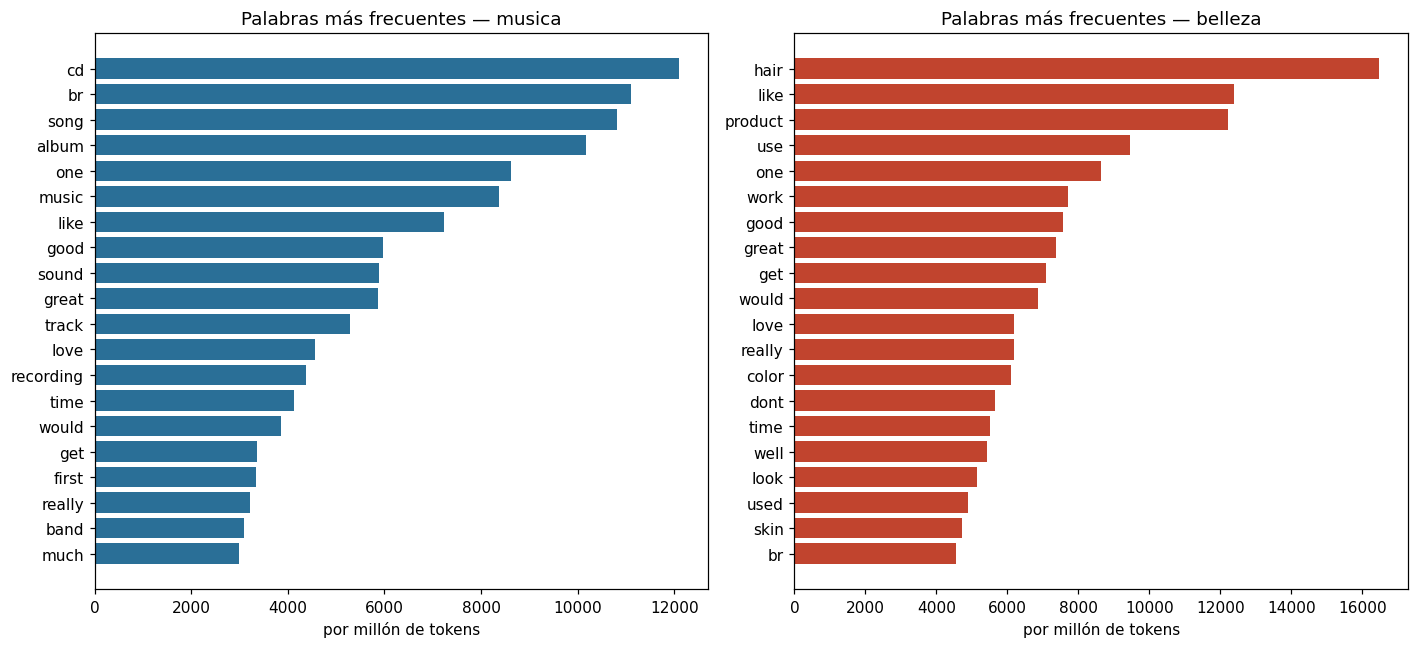

In [6]:
def por_millon(contador, n_tokens, k=20):
    llaves, vals = [], []
    for llave, n in contador.most_common(k):
        llaves.append(" ".join(llave) if isinstance(llave, tuple) else llave)
        vals.append(n / n_tokens * 1e6)
    return pd.Series(vals, index=llaves)


fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, cat in zip(axes, CATS):
    s = por_millon(frec[cat], total[cat])[::-1]
    ax.barh(s.index, s.values, color=COLOR[cat])
    ax.set_title(f"Palabras más frecuentes — {cat}")
    ax.set_xlabel("por millón de tokens")

plt.tight_layout()
plt.savefig(FIG / "2_palabras_frecuentes.png")
plt.show()

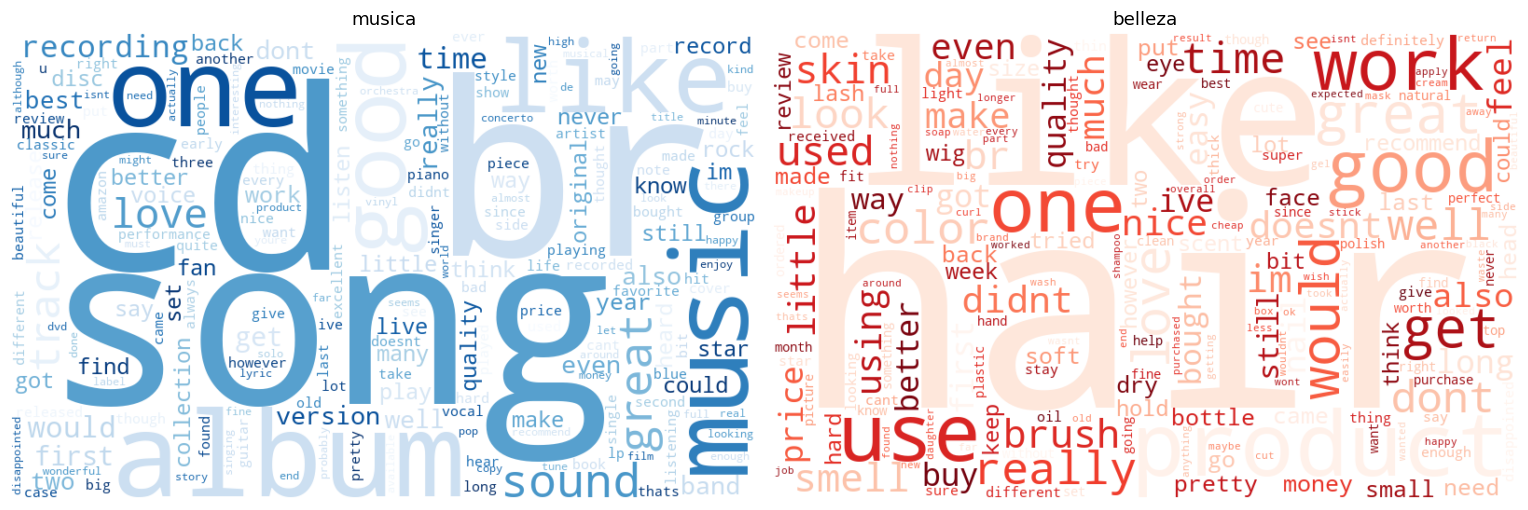

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cat in zip(axes, CATS):
    nube = WordCloud(width=800, height=500, background_color="white",
                     colormap="Blues" if cat == "musica" else "Reds",
                     random_state=42).generate_from_frequencies(frec[cat])
    ax.imshow(nube, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(cat)

plt.tight_layout()
plt.savefig(FIG / "3_nubes.png")
plt.show()

---
## 4. Palabras que distinguen a cada categoría

Las listas de arriba se parecen porque las palabras muy frecuentes son frecuentes en todas partes.
Lo interesante es la **razón** entre ambas categorías: qué palabra es mucho más común en una que
en la otra.

Dos cuidados:

1. Se exige un mínimo de 200 apariciones combinadas, para no quedarse con rarezas que salen 3 veces.
2. Hay palabras que aparecen **cero veces** en una categoría (`elvis` no sale en reseñas de
   champú). La razón sería división entre cero. Se suma 1 a cada conteo antes de dividir
   —suavizado de Laplace— para que la razón siempre exista.

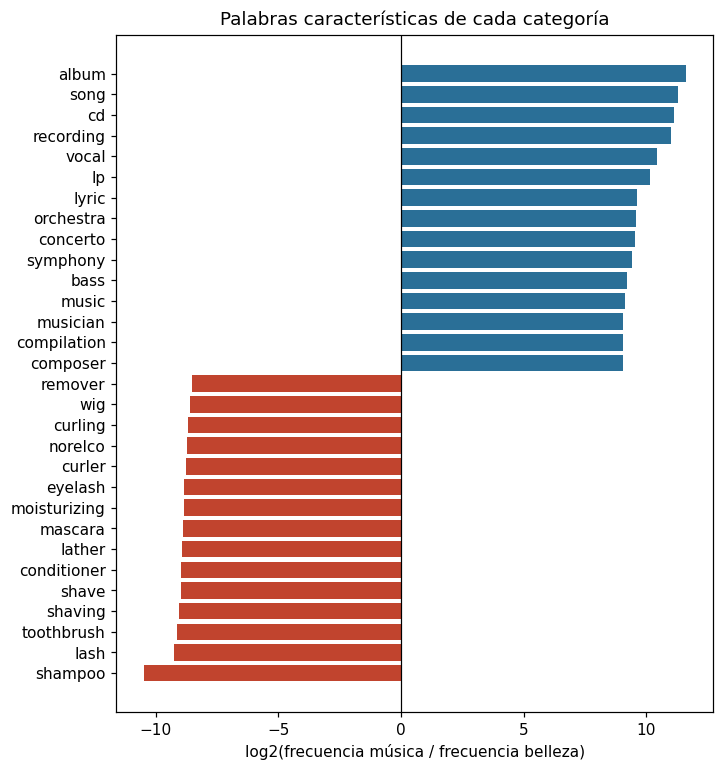

Belleza: shampoo, lash, toothbrush, shaving, shave, conditioner, lather, mascara, moisturizing, eyelash
Música : album, song, cd, recording, vocal, lp, lyric, orchestra, concerto, symphony


In [8]:
UMBRAL = 200

vocabulario = set(frec["musica"]) | set(frec["belleza"])
comunes = [w for w in vocabulario
           if frec["musica"][w] + frec["belleza"][w] >= UMBRAL]

# +1 en el conteo: suavizado de Laplace, evita dividir entre cero
tabla = pd.DataFrame({
    cat: [(frec[cat][w] + 1) / total[cat] * 1e6 for w in comunes] for cat in CATS
}, index=comunes)
tabla["razon"] = tabla["musica"] / tabla["belleza"]
tabla = tabla.sort_values("razon")

assert np.isfinite(tabla["razon"]).all(), "quedaron razones infinitas"

extremos = pd.concat([tabla.head(15), tabla.tail(15)])

fig, ax = plt.subplots(figsize=(7, 8))
colores = [COLOR["belleza"] if r < 1 else COLOR["musica"] for r in extremos["razon"]]
ax.barh(extremos.index, np.log2(extremos["razon"]), color=colores)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("log2(frecuencia música / frecuencia belleza)")
ax.set_title("Palabras características de cada categoría")
plt.savefig(FIG / "4_palabras_distintivas.png")
plt.show()

print("Belleza:", ", ".join(tabla.head(10).index))
print("Música :", ", ".join(tabla.tail(10).index[::-1]))

---
## 5. Bigramas

Pares de palabras consecutivas. Se calculan sobre los tokens ya lematizados, así que reflejan
combinaciones de contenido, no de gramática.

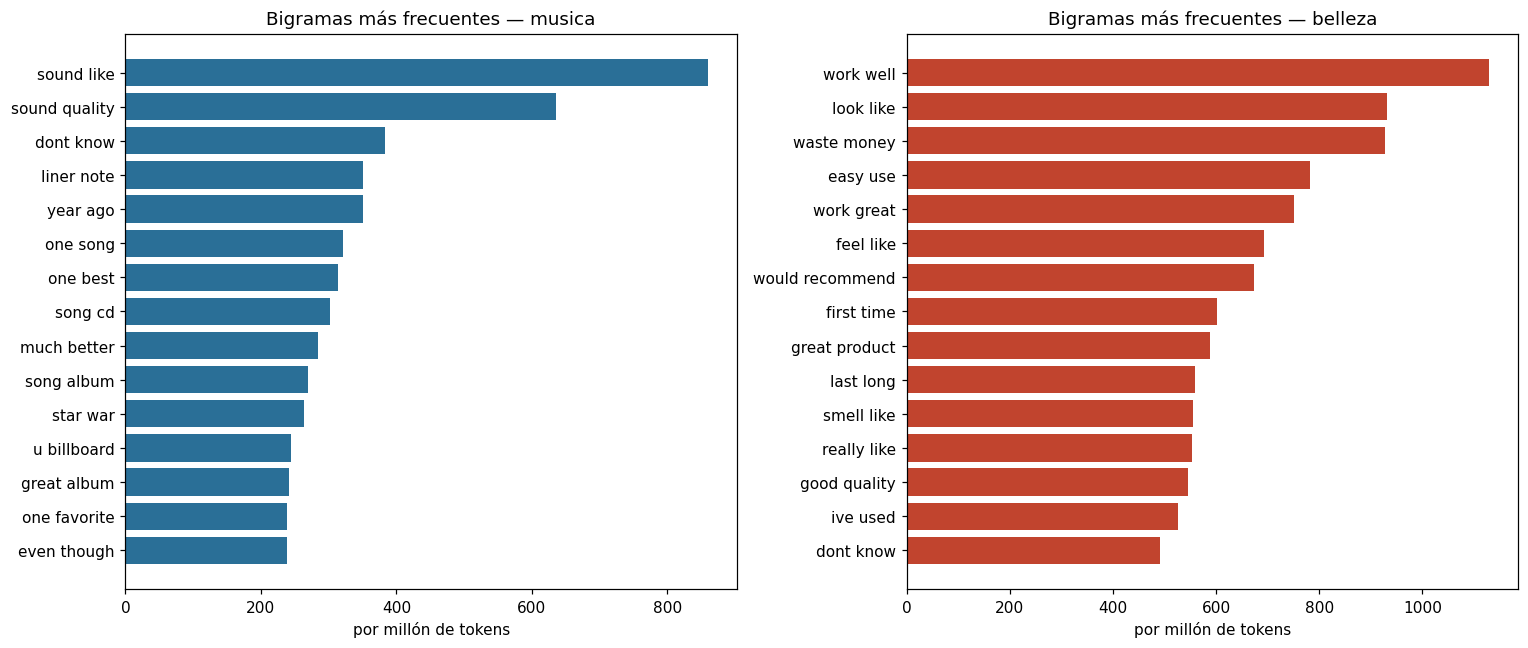

In [9]:
bigramas = {cat: Counter(ngrams(tokens[cat], 2)) for cat in CATS}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, cat in zip(axes, CATS):
    s = por_millon(bigramas[cat], total[cat], k=15)[::-1]
    ax.barh(s.index, s.values, color=COLOR[cat])
    ax.set_title(f"Bigramas más frecuentes — {cat}")
    ax.set_xlabel("por millón de tokens")

plt.tight_layout()
plt.savefig(FIG / "5_bigramas.png")
plt.show()

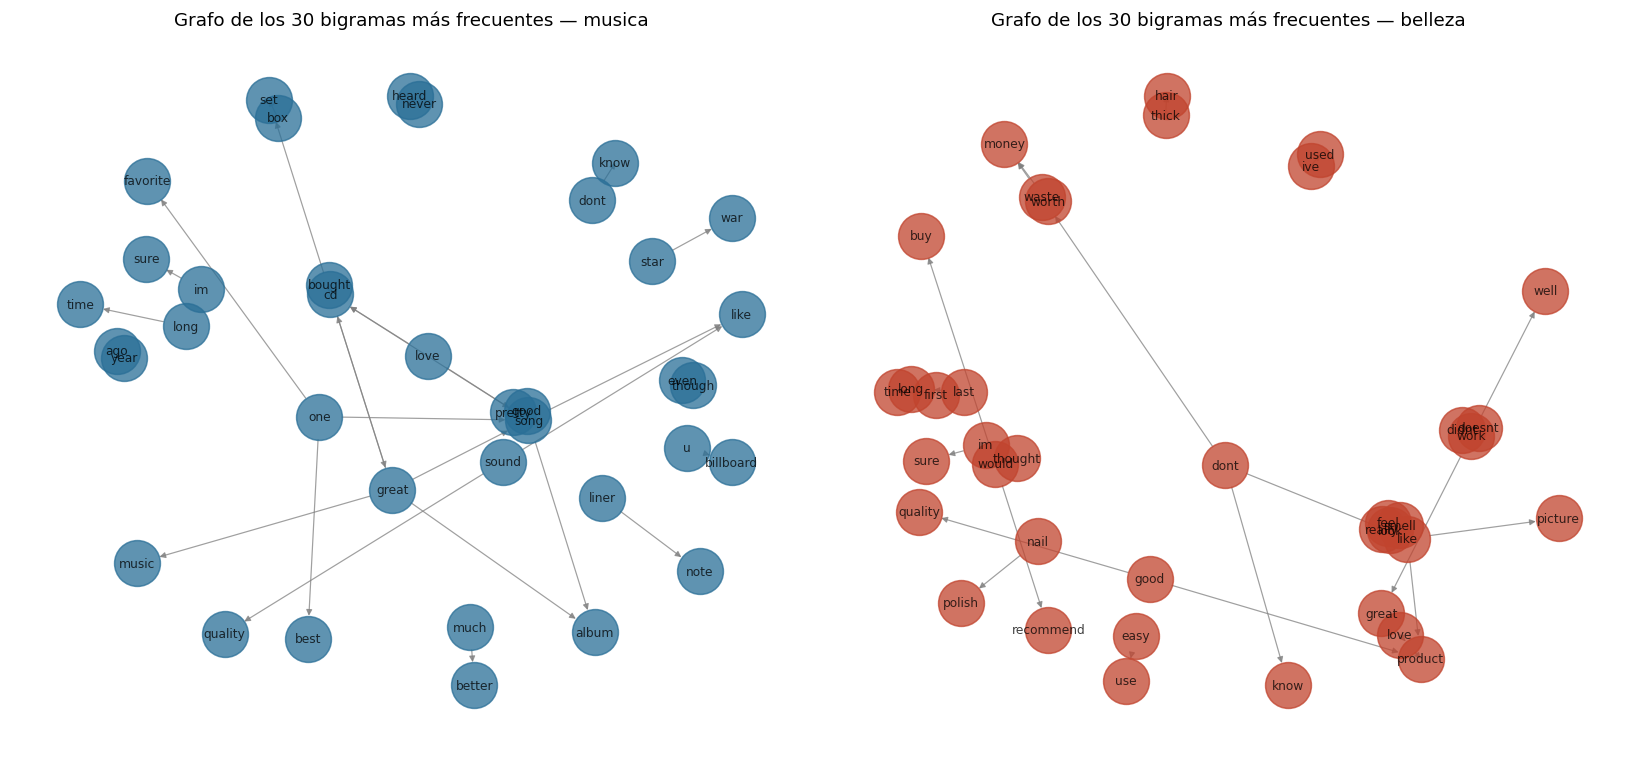

In [10]:
# grafo de bigramas, como en clase
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for ax, cat in zip(axes, CATS):
    G = nx.DiGraph()
    for (a, b), n in bigramas[cat].most_common(30):
        G.add_edge(a, b, weight=n)

    pos = nx.spring_layout(G, k=0.6, seed=42)
    nx.draw(G, pos, ax=ax, with_labels=True, node_size=900, font_size=8,
            node_color=COLOR[cat], alpha=0.75, edge_color="gray",
            arrowsize=8, width=0.8)
    ax.set_title(f"Grafo de los 30 bigramas más frecuentes — {cat}")

plt.tight_layout()
plt.savefig(FIG / "6_grafo_bigramas.png")
plt.show()

---
## 6. Signos de puntuación

Sobre el **texto crudo**, normalizado por cada 1,000 caracteres.

A diferencia de una transcripción, aquí la puntuación sí la escribió el autor. No hay intermediario.

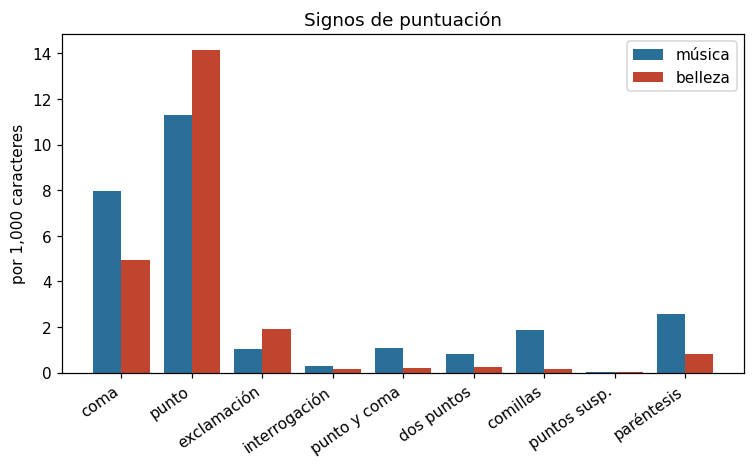

,musica,belleza,razón
coma,7.988,4.948,1.61
punto,11.305,14.152,0.80
exclamación,1.055,1.897,0.56
interrogación,0.286,0.144,1.99
punto y coma,1.090,0.211,5.17
dos puntos,0.800,0.232,3.45
comillas,1.858,0.180,10.32
puntos susp.,0.013,0.032,0.41
paréntesis,2.553,0.798,3.20


In [11]:
SIGNOS = {"coma": ",", "punto": ".", "exclamación": "!", "interrogación": "?",
          "punto y coma": ";", "dos puntos": ":", "comillas": '"',
          "puntos susp.": "…", "paréntesis": "()"}

crudo = {cat: " ".join(g["text"]) for cat, g in datos.groupby("categoria")}

punt = pd.DataFrame({
    cat: {nom: sum(crudo[cat].count(ch) for ch in chars) / len(crudo[cat]) * 1000
          for nom, chars in SIGNOS.items()}
    for cat in CATS
}).round(3)
punt["razón"] = (punt["musica"] / punt["belleza"]).round(2)

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(len(punt))
ax.bar(x - 0.2, punt["musica"], 0.4, label="música", color=COLOR["musica"])
ax.bar(x + 0.2, punt["belleza"], 0.4, label="belleza", color=COLOR["belleza"])
ax.set_xticks(x); ax.set_xticklabels(punt.index, rotation=35, ha="right")
ax.set_ylabel("por 1,000 caracteres")
ax.set_title("Signos de puntuación")
ax.legend()
plt.savefig(FIG / "7_puntuacion.png")
plt.show()

punt

---
## 7. Emojis

Las reseñas de Amazon sí traen emojis, aunque en proporción pequeña. Se detectan por rango
Unicode.

           reseñas con emoji  proporción
categoria                               
belleza                  824      0.0165
musica                   265      0.0076


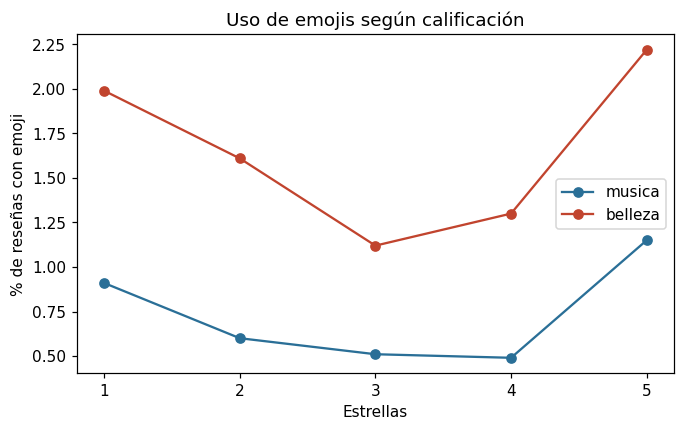

rating,1,2,3,4,5
categoria,,,,,
belleza,1.99,1.61,1.12,1.30,2.22
musica,0.91,0.60,0.51,0.49,1.15


In [12]:
PATRON_EMOJI = re.compile(
    "[\U0001F300-\U0001FAFF"   # símbolos, pictogramas, emoticones
    "\U00002600-\U000027BF"    # misceláneos y dingbats
    "\U0001F1E6-\U0001F1FF]"   # banderas
)

datos["emojis"] = datos["text"].apply(lambda t: PATRON_EMOJI.findall(t))
datos["tiene_emoji"] = datos["emojis"].str.len() > 0

uso = datos.groupby("categoria")["tiene_emoji"].agg(["sum", "mean"])
uso.columns = ["reseñas con emoji", "proporción"]
print(uso.round(4))

# ¿los emojis se concentran en alguna calificación?
tabla_emoji = (datos.groupby(["categoria", "rating"])["tiene_emoji"]
               .mean().unstack() * 100).round(2)

fig, ax = plt.subplots(figsize=(7, 4))
for cat in CATS:
    ax.plot(tabla_emoji.columns, tabla_emoji.loc[cat], "o-",
            label=cat, color=COLOR[cat])
ax.set_xlabel("Estrellas")
ax.set_ylabel("% de reseñas con emoji")
ax.set_title("Uso de emojis según calificación")
ax.set_xticks([1, 2, 3, 4, 5])
ax.legend()
plt.savefig(FIG / "8_emojis.png")
plt.show()

tabla_emoji

In [13]:
top_emoji = {cat: Counter(e for lista in g["emojis"] for e in lista).most_common(8)
             for cat, g in datos.groupby("categoria")}
for cat in CATS:
    print(f"{cat}: " + "  ".join(f"{e} ({n})" for e, n in top_emoji[cat]))

musica: ❤ (36)  😭 (19)  🎶 (17)  💜 (13)  🔥 (13)  👍 (12)  ☺ (12)  👎 (11)
belleza: 😍 (79)  ♀ (78)  😡 (59)  ❤ (53)  👍 (51)  👎 (44)  😒 (43)  🤷 (41)


---
## 8. Generar el reporte

Escribe `README.md` con los números ya insertados.

In [14]:
def f(x, d=0):
    return f"{x:,.{d}f}"


mas_belleza = ", ".join(f"`{w}`" for w in tabla.head(8).index)
mas_musica = ", ".join(f"`{w}`" for w in tabla.tail(8).index[::-1])

reporte = f"""# Tarea 1 — Análisis textual

**Procesamiento y Clasificación de Datos · MCD, FCFM-UANL**

## Pregunta

¿Escribe distinto quien reseña música que quien reseña productos de belleza?

Son dos comunidades de autores en la misma plataforma, con el mismo formato de reseña y el mismo
sistema de estrellas. Si el estilo difiere, difiere por el objeto reseñado.

## Datos

[Amazon Reviews 2023](https://amazon-reviews-2023.github.io/) (McAuley Lab, UCSD). Dos categorías:
`Digital_Music` y `All_Beauty`.

Muestreo estratificado por estrella, sin duplicados de texto, mínimo tres palabras por reseña.

| | Música | Belleza |
|---|---:|---:|
| Reseñas | {f(resumen.loc['Reseñas', 'musica'])} | {f(resumen.loc['Reseñas', 'belleza'])} |
| Palabras totales | {f(resumen.loc['Palabras totales', 'musica'])} | {f(resumen.loc['Palabras totales', 'belleza'])} |
| Tokens tras limpieza | {f(total['musica'])} | {f(total['belleza'])} |
| Palabras distintas | {f(len(frec['musica']))} | {f(len(frec['belleza']))} |

Belleza alcanzó el tope de 10,000 reseñas en las cinco estrellas; música se quedó corta en 1★, 2★
y 3★ porque hay pocas reseñas negativas de discos. Se documenta el desbalance y se corrige donde
importa: **toda frecuencia se reporta por millón de tokens**, nunca en conteo bruto. Comparar
conteos brutos entre corpus de distinto tamaño produce diferencias que solo reflejan el tamaño.

## Estadística descriptiva

![Descriptivos](figuras/1_descriptivos.png)

| | Música | Belleza |
|---|---:|---:|
| Palabras por reseña (media) | {f(resumen.loc['Palabras por reseña (media)', 'musica'], 1)} | {f(resumen.loc['Palabras por reseña (media)', 'belleza'], 1)} |
| Palabras por reseña (mediana) | {f(resumen.loc['Palabras por reseña (mediana)', 'musica'])} | {f(resumen.loc['Palabras por reseña (mediana)', 'belleza'])} |
| Caracteres por reseña (media) | {f(resumen.loc['Caracteres por reseña (media)', 'musica'], 1)} | {f(resumen.loc['Caracteres por reseña (media)', 'belleza'], 1)} |
| Caracteres por palabra | {f(resumen.loc['Densidad (media)', 'musica'], 2)} | {f(resumen.loc['Densidad (media)', 'belleza'], 2)} |

Quien reseña música escribe más del doble. Pero la densidad —caracteres por palabra— es casi
idéntica. La diferencia está en **cuánto** escriben, no en qué tan largas son sus palabras.

## Palabras frecuentes

![Palabras frecuentes](figuras/2_palabras_frecuentes.png)

![Nubes de palabras](figuras/3_nubes.png)

## Palabras que distinguen

![Palabras distintivas](figuras/4_palabras_distintivas.png)

Características de **música**: {mas_musica}

Características de **belleza**: {mas_belleza}

## Bigramas

![Bigramas](figuras/5_bigramas.png)

![Grafo de bigramas](figuras/6_grafo_bigramas.png)

## Puntuación

![Puntuación](figuras/7_puntuacion.png)

Por cada 1,000 caracteres:

| Signo | Música | Belleza | Razón |
|---|---:|---:|---:|
""" + "\n".join(
    f"| {i} | {punt.loc[i, 'musica']} | {punt.loc[i, 'belleza']} | {punt.loc[i, 'razón']} |"
    for i in punt.index
) + f"""

A diferencia de una transcripción, aquí la puntuación la escribió el propio autor: no hay
intermediario que la introduzca.

## Emojis

![Emojis](figuras/8_emojis.png)

| | Reseñas con emoji | Proporción |
|---|---:|---:|
| Música | {f(uso.loc['musica', 'reseñas con emoji'])} | {uso.loc['musica', 'proporción'] * 100:.2f} % |
| Belleza | {f(uso.loc['belleza', 'reseñas con emoji'])} | {uso.loc['belleza', 'proporción'] * 100:.2f} % |

Belleza usa emojis con más del doble de frecuencia que música.

## Conclusiones

1. **Extensión.** Las reseñas de música son más del doble de largas
   ({f(resumen.loc['Palabras por reseña (media)', 'musica'], 1)} contra
   {f(resumen.loc['Palabras por reseña (media)', 'belleza'], 1)} palabras). La densidad léxica
   es prácticamente igual: escriben más, no más complicado.

2. **Vocabulario.** Música gira en torno a juicios estéticos; belleza, en torno a resultados
   materiales y experiencia de uso del producto.

3. **Emojis.** Belleza los usa al doble. Es coherente con un registro más informal y conversacional.

4. En conjunto, la categoría del producto condiciona **cómo** se escribe la reseña, no solo de qué
   se habla. Un lector humano distinguiría el origen de una reseña sin ver el producto — lo que
   sugiere que un clasificador también podría.

## Limitaciones

- La muestra estratificada no refleja la distribución real de estrellas en Amazon, que está muy
  sesgada hacia 5★. Es deliberado, para las tareas siguientes.
- Música tiene pocas reseñas de 1★–3★ disponibles; su muestra es menor.
- No se verificó la autenticidad de las reseñas; Amazon contiene reseñas incentivadas.
- Todas las reseñas están en inglés.

## Reproducir

1. Correr `comun/descargar_datos.ipynb` (descarga y muestreo).
2. Correr `Tarea1/analisis_textual.ipynb`.

Requiere `pandas`, `numpy`, `matplotlib`, `nltk`, `wordcloud`, `networkx`.

## Referencias

- Hou, Y., Li, J., He, Z., Yan, A., Chen, X., & McAuley, J. (2024). *Bridging Language and Items
  for Retrieval and Recommendation*. arXiv:2403.03952.
- Bird, S., Klein, E., & Loper, E. (2009). *Natural Language Processing with Python*. O'Reilly.
"""

Path("README.md").write_text(reporte, encoding="utf-8")
print("README.md escrito ✓")

README.md escrito ✓
